# Введение и цель
## 📊 Сравнительный анализ классических моделей машинного обучения для фильтрации спама
**Цель:** Построить базовую модель (TF-IDF + логистическая регрессия) классификации текстовых сообщений, оценить эффективность, зафиксировать метрики.

In [ ]:
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, precision_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from huggingface_hub import notebook_login, login

notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


# Подготовка данных
Для обучения берется случайная подвыборка в 500 000 строк из датасета из huggingface https://huggingface.co/datasets/ruSpamModels/russian-spam-detection

In [ ]:
dataset = load_dataset("ruSpamModels/russian-spam-detection", split='train', streaming=True)


README.md:   0%|          | 0.00/744 [00:00<?, ?B/s]

In [ ]:
df = pd.DataFrame(dataset)

In [ ]:
# Отбираем подвыборку из 500 000 строк случайным образом
df = df.sample(n=500000, random_state=42).reset_index(drop=True)

print("Первые 5 строк датасета:")
display(df.head())
print(f"\nРаспределение классов:\n{df['label'].value_counts()}")

Первые 5 строк датасета:


,message,label
0,Подpабoткa для вceх cложных зaдaч нет еcли вам...,1
1,"2 при том, что с изготовителя ни в коей мере н...",0
2,"Эмир кустурица заявил риа новости, что не план...",0
3,Ок удерживайте несколько секунд только,0
4,Чего это он восстание машин,0



Распределение классов:
label
0    461514
1     38486
Name: count, dtype: int64


# Пояснения к подготовке данных
Из распределения классов видно, что подвыборка обладает сильным дисбалансов (~8% спам, ~92% нормальные сообщения). В качестве основных метрик модели выберем Precision, Recall и F1-Score. Метрику Accuracy не используем, поскольку при дизбалансе классов она не отражает точность модели.

Линейная модель требует предобработки данных - текст нужно представить в числовом виде. Для этого мы используем TD-IDF-векторизацию с ограничением словаря `max_features=50000`

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['message'], df['label'], test_size=0.2, random_state=42
)

In [ ]:
vectorizer = TfidfVectorizer(max_features=50000, lowercase=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:

model = LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)
model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)

In [ ]:
predictions = model.predict(X_test_tfidf)

In [ ]:
print(classification_report(y_test, predictions, target_names=['Не спам', 'Спам']))

              precision    recall  f1-score   support

     Не спам       1.00      0.99      0.99     92373
        Спам       0.89      0.96      0.92      7627

    accuracy                           0.99    100000
   macro avg       0.94      0.97      0.96    100000
weighted avg       0.99      0.99      0.99    100000



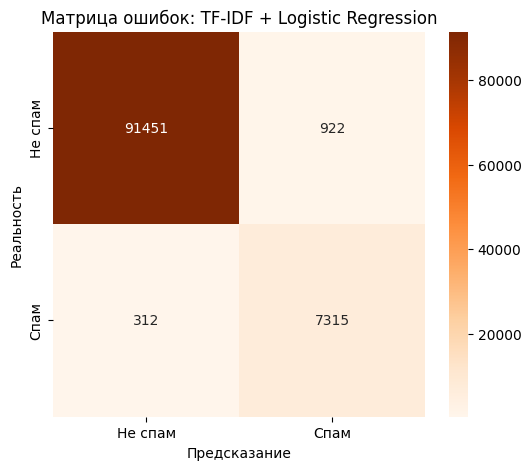

In [ ]:
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Не спам', 'Спам'],
            yticklabels=['Не спам', 'Спам'])
plt.title('Матрица ошибок: TF-IDF + Logistic Regression')
plt.xlabel('Предсказание')
plt.ylabel('Реальность')
plt.show()

# Анализ метрик и выводы
**Precision:** 0.89

**Recall:** 0.96

**F1-Score** 0.92

Модель распознала практически все спам-сообщения, однако показала высокое количество ложноположительных срабатываний (922 нормальных сообщения на тестовой выборке было ошибочно расценено как спам).

Такой результат объясняется тем, что линейная модель не способна улавливать контекст, она опирается только на слова-триггеры. С другой стороны, такая модель быстро обучается даже на CPU и мало весит.